In [8]:
"""
Cell 1: Setup and Simulation (Run this first)
"""

import mujoco
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
import time

print("=" * 80)
print("TENDON-DRIVEN 2R PLANAR MECHANISM - SEPARATE VISUALIZATIONS")
print("=" * 80)

# -------------------------------------------------------------------
# 1. PARAMETERS (YOUR EXACT DIMENSIONS)
# -------------------------------------------------------------------
R1 = 0.01   # Pulley 1 radius (m)
R2 = 0.026  # Pulley 2 radius (m)
a = 0.037   # Link 1 length (m)
c = 0.045   # Link 2 length (m)
b = 0.052   # Link 3 length (m)

print(f"\n📏 MODEL PARAMETERS:")
print(f"  Pulley 1 radius (R1) = {R1} m")
print(f"  Pulley 2 radius (R2) = {R2} m")
print(f"  Link 1 length (a)    = {a} m")
print(f"  Link 2 length (c)    = {c} m")
print(f"  Link 3 length (b)    = {b} m")
print(f"  Total reach          = {a + b + c:.3f} m")

# -------------------------------------------------------------------
# 2. CREATE AND RUN SIMULATION
# -------------------------------------------------------------------
print("\n" + "="*50)
print("RUNNING SIMULATION")
print("="*50)

# Create XML
xml_string = f'''<mujoco>
  <option timestep="0.001"/>
  <option gravity="0 0 0"/>
  
  <worldbody>
    <light pos="0 0 1"/>
    
    <!-- Base wall -->
    <body name="wall" pos="0 0 0">
      <geom type="box" size="0.02 0.02 0.005"/>
      <site name="anchor_left" pos="-0.015 0 0" size="0.002"/>
      <site name="anchor_right" pos="0.015 0 0" size="0.002"/>
    </body>
    
    <!-- Mechanism -->
    <body name="link1" pos="0 0 0.005">
      <joint name="joint1" type="hinge" axis="0 0 1"/>
      <geom type="capsule" fromto="0 0 0 {a} 0 0" size="0.0025"/>
      
      <!-- First pulley -->
      <geom name="pulley1" type="cylinder" pos="0 0 0" size="{R1} 0.001" euler="0 90 0"/>
      <site name="p1_top" pos="0 {R1} 0" size="0.001"/>
      <site name="p1_bottom" pos="0 {-R1} 0" size="0.001"/>
      
      <!-- Second link -->
      <body name="link2" pos="{a} 0 0">
        <joint name="joint2" type="hinge" axis="0 0 1"/>
        <geom type="capsule" fromto="0 0 0 {c} 0 0" size="0.0025"/>
        
        <!-- Second pulley -->
        <geom name="pulley2" type="cylinder" pos="0 0 0" size="{R2} 0.001" euler="0 90 0"/>
        <site name="p2_top" pos="0 {R2} 0" size="0.001"/>
        <site name="p2_bottom" pos="0 {-R2} 0" size="0.001"/>
        
        <!-- Third link -->
        <body name="link3" pos="{c} 0 0">
          <geom type="capsule" fromto="0 0 0 {b} 0 0" size="0.0025"/>
          <site name="effector" pos="{b} 0 0" size="0.003"/>
          <site name="attach_top" pos="{b} {R2/2} 0" size="0.0015"/>
          <site name="attach_bottom" pos="{b} {-R2/2} 0" size="0.0015"/>
        </body>
      </body>
    </body>
  </worldbody>
  
  <tendon>
    <spatial name="tendon1" stiffness="200" damping="5">
      <site site="anchor_right"/>
      <site site="p1_top"/>
      <site site="p2_top"/>
      <site site="attach_top"/>
    </spatial>
    
    <spatial name="tendon2" stiffness="200" damping="5">
      <site site="anchor_left"/>
      <site site="p1_bottom"/>
      <site site="p2_bottom"/>
      <site site="attach_bottom"/>
    </spatial>
  </tendon>
  
</mujoco>'''

# Load model
model = mujoco.MjModel.from_xml_string(xml_string)
data = mujoco.MjData(model)

# Set initial conditions
if model.nq >= 1:
    data.qpos[0] = 0.5  # Joint 1 angle
if model.nq >= 2:
    data.qpos[1] = -0.3  # Joint 2 angle

mujoco.mj_forward(model, data)

# Run simulation
duration = 2.0
dt = model.opt.timestep
n_steps = int(duration / dt)

eff_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, "effector")

# Data storage
time_points = []
effector_x, effector_y = [], []
joint1_angles, joint2_angles = [], []

print(f"Simulating {n_steps:,} steps...")
for step in range(n_steps):
    time_points.append(step * dt)
    
    if eff_id >= 0:
        pos = data.site_xpos[eff_id]
        effector_x.append(pos[0])
        effector_y.append(pos[1])
    
    if model.nq >= 1:
        joint1_angles.append(data.qpos[0])
    if model.nq >= 2:
        joint2_angles.append(data.qpos[1])
    
    # Step simulation
    mujoco.mj_step(model, data)
    
    if step % (n_steps // 10) == 0:
        progress = (step / n_steps) * 100
        print(f"  Progress: {progress:.0f}%")

print(f"\n✓ Simulation complete: {len(time_points)} data points")

# Calculate velocities for later
if len(effector_x) > 1:
    dt_array = np.diff(time_points[:len(effector_x)])
    vx = np.diff(effector_x) / dt_array
    vy = np.diff(effector_y) / dt_array
    velocity_magnitude = np.sqrt(vx**2 + vy**2)
    time_vel = time_points[1:len(effector_x)]

print("\n✅ Simulation data ready for visualization")

TENDON-DRIVEN 2R PLANAR MECHANISM - SEPARATE VISUALIZATIONS

📏 MODEL PARAMETERS:
  Pulley 1 radius (R1) = 0.01 m
  Pulley 2 radius (R2) = 0.026 m
  Link 1 length (a)    = 0.037 m
  Link 2 length (c)    = 0.045 m
  Link 3 length (b)    = 0.052 m
  Total reach          = 0.134 m

RUNNING SIMULATION
Simulating 2,000 steps...
  Progress: 0%
  Progress: 10%
  Progress: 20%
  Progress: 30%
  Progress: 40%
  Progress: 50%
  Progress: 60%
  Progress: 70%
  Progress: 80%
  Progress: 90%

✓ Simulation complete: 2000 data points

✅ Simulation data ready for visualization



CREATING SCHEMATIC DIAGRAM (Figure 1)


/var/folders/b9/5qs213z516xddymdmnr48z0w0000gn/T/ipykernel_25232/1624203387.py:76: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  pulley1 = Circle(joint1, R1, fill=True, color='#FF9800', alpha=0.7,
/var/folders/b9/5qs213z516xddymdmnr48z0w0000gn/T/ipykernel_25232/1624203387.py:79: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  pulley2 = Circle(joint2, R2, fill=True, color='#7B1FA2', alpha=0.7,


✓ Schematic saved as 'figure1_schematic.png'


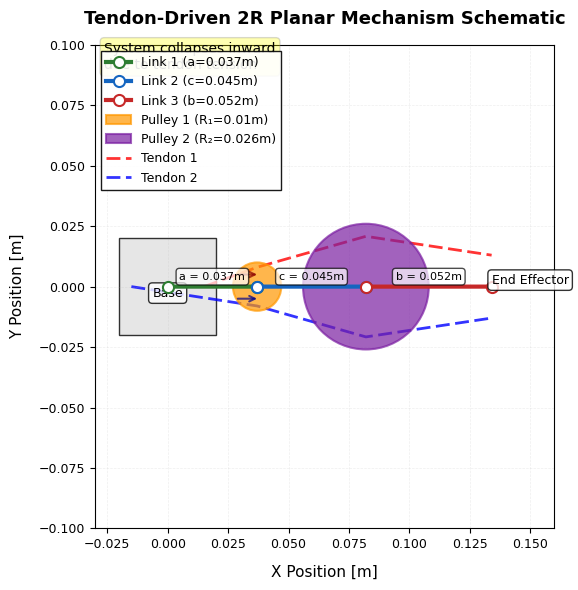

In [9]:
"""
Cell 2: Create SCHEMATIC DIAGRAM (Figure 1)
"""

print("\n" + "="*50)
print("CREATING SCHEMATIC DIAGRAM (Figure 1)")
print("="*50)

# Set up professional style
plt.style.use('default')
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

# Create figure for schematic
fig1, ax1 = plt.subplots(figsize=(8, 6))
ax1.set_aspect('equal')
ax1.set_xlim(-0.03, 0.16)
ax1.set_ylim(-0.1, 0.1)
ax1.set_xlabel('X Position [m]', fontsize=11, labelpad=10)
ax1.set_ylabel('Y Position [m]', fontsize=11, labelpad=10)
ax1.set_title('Tendon-Driven 2R Planar Mechanism Schematic', 
              fontsize=13, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)

# Calculate positions (using final joint angles or default)
if len(joint1_angles) > 0 and len(joint2_angles) > 0:
    theta1 = joint1_angles[-1]
    theta2 = joint2_angles[-1]
    base = np.array([0, 0])
    joint1 = np.array([a * np.cos(theta1), a * np.sin(theta1)])
    joint2 = joint1 + np.array([c * np.cos(theta1 + theta2), c * np.sin(theta1 + theta2)])
    effector_pos = joint2 + np.array([b * np.cos(theta1 + theta2), b * np.sin(theta1 + theta2)])
else:
    base = np.array([0, 0])
    joint1 = np.array([a * 0.85, a * 0.15])
    joint2 = np.array([(a + c) * 0.75, (a + c) * 0.08])
    effector_pos = np.array([(a + b + c) * 0.65, (a + b + c) * 0.03])

# 1. Draw wall/base
wall = Rectangle((-0.02, -0.02), 0.04, 0.04, 
                 facecolor='#E0E0E0', edgecolor='black', 
                 linewidth=1, alpha=0.8, zorder=1)
ax1.add_patch(wall)
ax1.text(0, 0, 'Base', ha='center', va='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 2. Draw links
link_colors = ['#2E7D32', '#1565C0', '#C62828']  # Green, Blue, Red
link_labels = [f'Link 1 (a={a}m)', f'Link 2 (c={c}m)', f'Link 3 (b={b}m)']

# Link 1
ax1.plot([base[0], joint1[0]], [base[1], joint1[1]], 
         'o-', color=link_colors[0], linewidth=3, markersize=8,
         markerfacecolor='white', markeredgewidth=1.5, 
         markeredgecolor=link_colors[0], label=link_labels[0], zorder=3)

# Link 2
ax1.plot([joint1[0], joint2[0]], [joint1[1], joint2[1]], 
         'o-', color=link_colors[1], linewidth=3, markersize=8,
         markerfacecolor='white', markeredgewidth=1.5, 
         markeredgecolor=link_colors[1], label=link_labels[1], zorder=3)

# Link 3
ax1.plot([joint2[0], effector_pos[0]], [joint2[1], effector_pos[1]], 
         'o-', color=link_colors[2], linewidth=3, markersize=8,
         markerfacecolor='white', markeredgewidth=1.5, 
         markeredgecolor=link_colors[2], label=link_labels[2], zorder=3)

# 3. Draw pulleys
pulley1 = Circle(joint1, R1, fill=True, color='#FF9800', alpha=0.7, 
                 edgecolor='#E65100', linewidth=1.5, zorder=2,
                 label=f'Pulley 1 (R₁={R1}m)')
pulley2 = Circle(joint2, R2, fill=True, color='#7B1FA2', alpha=0.7,
                 edgecolor='#4A148C', linewidth=1.5, zorder=2,
                 label=f'Pulley 2 (R₂={R2}m)')
ax1.add_patch(pulley1)
ax1.add_patch(pulley2)

# 4. Draw tendons
# Top tendon (red)
tendon_top_x = [0.015, joint1[0], joint2[0], effector_pos[0]]
tendon_top_y = [0, joint1[1] + R1*0.8, joint2[1] + R2*0.8, effector_pos[1] + R2/2]
ax1.plot(tendon_top_x, tendon_top_y, 'r--', linewidth=2, 
         alpha=0.8, label='Tendon 1', zorder=1, dashes=(5, 2))

# Bottom tendon (blue)
tendon_bottom_x = [-0.015, joint1[0], joint2[0], effector_pos[0]]
tendon_bottom_y = [0, joint1[1] - R1*0.8, joint2[1] - R2*0.8, effector_pos[1] - R2/2]
ax1.plot(tendon_bottom_x, tendon_bottom_y, 'b--', linewidth=2, 
         alpha=0.8, label='Tendon 2', zorder=1, dashes=(5, 2))

# 5. Add tension arrows
arrow_props_red = dict(arrowstyle='->', color='darkred', lw=1.5, 
                       shrinkA=0, shrinkB=0, alpha=0.7)
arrow_props_blue = dict(arrowstyle='->', color='darkblue', lw=1.5, 
                        shrinkA=0, shrinkB=0, alpha=0.7)

ax1.annotate('', xy=(joint1[0], joint1[1] + R1*0.5),
             xytext=(joint1[0] - 0.008, joint1[1] + R1*0.5),
             arrowprops=arrow_props_red)

ax1.annotate('', xy=(joint1[0], joint1[1] - R1*0.5),
             xytext=(joint1[0] - 0.008, joint1[1] - R1*0.5),
             arrowprops=arrow_props_blue)

# 6. Add labels and annotations
ax1.text(effector_pos[0], effector_pos[1], 'End Effector', 
         ha='left', va='bottom', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Collapse annotation
ax1.text(0.02, 0.95, 'System collapses inward\ndue to tendon tension', 
         transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='yellow', 
                   alpha=0.3, edgecolor='gray'))

# 7. Add legend
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9, 
           edgecolor='black', fancybox=False)

# 8. Add dimension annotations
# Link lengths
ax1.annotate(f'a = {a}m', xy=((base[0] + joint1[0])/2, (base[1] + joint1[1])/2),
             xytext=(0, 5), textcoords='offset points', ha='center', 
             fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax1.annotate(f'c = {c}m', xy=((joint1[0] + joint2[0])/2, (joint1[1] + joint2[1])/2),
             xytext=(0, 5), textcoords='offset points', ha='center', 
             fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax1.annotate(f'b = {b}m', xy=((joint2[0] + effector_pos[0])/2, (joint2[1] + effector_pos[1])/2),
             xytext=(0, 5), textcoords='offset points', ha='center', 
             fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()

# Save schematic
schematic_file = 'figure1_schematic.png'
plt.savefig(schematic_file, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Schematic saved as '{schematic_file}'")

plt.show()


CREATING SIMULATION RESULTS (Figure 2)
✓ Results figure saved as 'figure2_results.png'


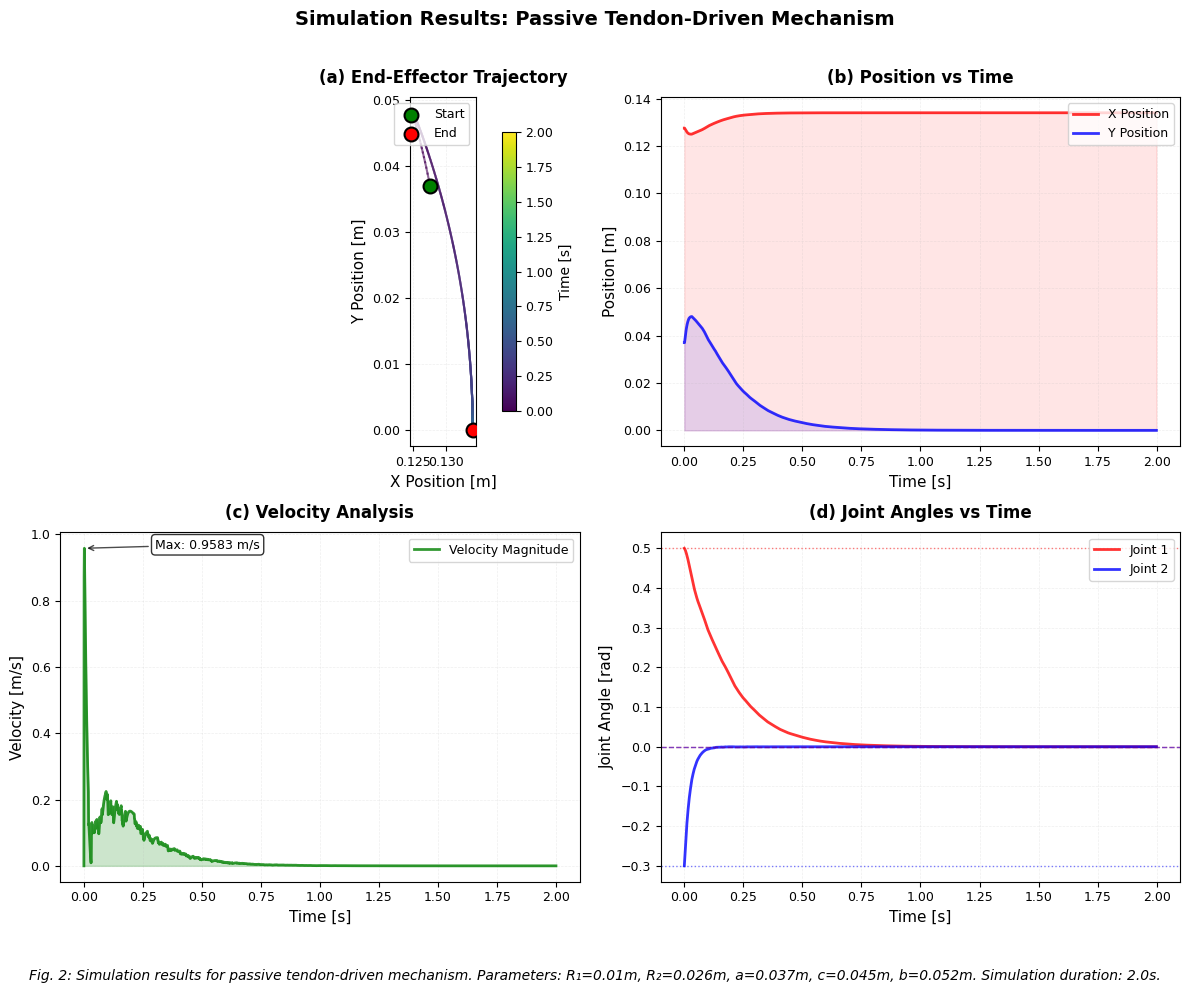

In [10]:
"""
Cell 3: Create SIMULATION RESULTS (Figure 2)
"""

print("\n" + "="*50)
print("CREATING SIMULATION RESULTS (Figure 2)")
print("="*50)

# Create figure with 2x2 subplots
fig2, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

plt.suptitle('Simulation Results: Passive Tendon-Driven Mechanism', 
             fontsize=14, fontweight='bold', y=0.98)

# -------------------------------------------------------------------
# Subplot 1: Trajectory
# -------------------------------------------------------------------
ax1.set_aspect('equal')
if len(effector_x) > 0 and len(effector_y) > 0:
    # Color by time
    colors = plt.cm.viridis(np.linspace(0, 1, len(effector_x)))
    
    for i in range(len(effector_x)-1):
        ax1.plot(effector_x[i:i+2], effector_y[i:i+2], 
                color=colors[i], linewidth=1.5, alpha=0.6)
    
    # Mark start and end
    ax1.scatter(effector_x[0], effector_y[0], color='green', 
               s=100, label='Start', zorder=5, 
               edgecolors='black', linewidth=1.5)
    ax1.scatter(effector_x[-1], effector_y[-1], color='red', 
               s=100, label='End', zorder=5, 
               edgecolors='black', linewidth=1.5)
    
    ax1.set_xlabel('X Position [m]', fontsize=11)
    ax1.set_ylabel('Y Position [m]', fontsize=11)
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap='viridis', 
                               norm=plt.Normalize(vmin=0, vmax=duration))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax1, shrink=0.8)
    cbar.set_label('Time [s]', fontsize=10)
else:
    ax1.text(0.5, 0.5, 'No trajectory data', 
            ha='center', va='center', transform=ax1.transAxes)
ax1.set_title('(a) End-Effector Trajectory', fontsize=12, fontweight='bold', pad=10)

# -------------------------------------------------------------------
# Subplot 2: Position vs Time
# -------------------------------------------------------------------
if len(effector_x) > 0:
    time_array = np.array(time_points[:len(effector_x)])
    ax2.plot(time_array, effector_x, 'r-', linewidth=2, 
            label='X Position', alpha=0.8)
    ax2.plot(time_array, effector_y, 'b-', linewidth=2, 
            label='Y Position', alpha=0.8)
    
    ax2.set_xlabel('Time [s]', fontsize=11)
    ax2.set_ylabel('Position [m]', fontsize=11)
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
    
    # Fill between for visual clarity
    ax2.fill_between(time_array, effector_x, alpha=0.1, color='red')
    ax2.fill_between(time_array, effector_y, alpha=0.1, color='blue')
else:
    ax2.text(0.5, 0.5, 'No position data', 
            ha='center', va='center', transform=ax2.transAxes)
ax2.set_title('(b) Position vs Time', fontsize=12, fontweight='bold', pad=10)

# -------------------------------------------------------------------
# Subplot 3: Velocity Analysis
# -------------------------------------------------------------------
if 'velocity_magnitude' in locals() and len(velocity_magnitude) > 0:
    ax3.plot(time_vel, velocity_magnitude, 'g-', linewidth=2, 
            label='Velocity Magnitude', alpha=0.8)
    
    ax3.set_xlabel('Time [s]', fontsize=11)
    ax3.set_ylabel('Velocity [m/s]', fontsize=11)
    ax3.legend(loc='upper right', fontsize=9)
    ax3.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
    
    # Fill under curve
    ax3.fill_between(time_vel, velocity_magnitude, alpha=0.2, color='green')
    
    # Annotate max velocity
    max_vel = np.max(velocity_magnitude)
    max_time = time_vel[np.argmax(velocity_magnitude)]
    ax3.annotate(f'Max: {max_vel:.4f} m/s', 
                xy=(max_time, max_vel),
                xytext=(max_time + 0.3, max_vel),
                arrowprops=dict(arrowstyle='->', color='black', alpha=0.7),
                fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
else:
    ax3.text(0.5, 0.5, 'No velocity data', 
            ha='center', va='center', transform=ax3.transAxes)
ax3.set_title('(c) Velocity Analysis', fontsize=12, fontweight='bold', pad=10)

# -------------------------------------------------------------------
# Subplot 4: Joint Angles
# -------------------------------------------------------------------
if len(joint1_angles) > 0:
    time_array_joints = np.array(time_points[:len(joint1_angles)])
    ax4.plot(time_array_joints, joint1_angles, 'r-', linewidth=2, 
            label='Joint 1', alpha=0.8)
    
    if len(joint2_angles) > 0:
        ax4.plot(time_array_joints, joint2_angles, 'b-', linewidth=2, 
                label='Joint 2', alpha=0.8)
    
    ax4.set_xlabel('Time [s]', fontsize=11)
    ax4.set_ylabel('Joint Angle [rad]', fontsize=11)
    ax4.legend(loc='upper right', fontsize=9)
    ax4.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
    
    # Add horizontal lines for initial/final values
    ax4.axhline(y=joint1_angles[0], color='r', linestyle=':', alpha=0.5, linewidth=1)
    ax4.axhline(y=joint1_angles[-1], color='r', linestyle='--', alpha=0.5, linewidth=1)
    
    if len(joint2_angles) > 0:
        ax4.axhline(y=joint2_angles[0], color='b', linestyle=':', alpha=0.5, linewidth=1)
        ax4.axhline(y=joint2_angles[-1], color='b', linestyle='--', alpha=0.5, linewidth=1)
else:
    ax4.text(0.5, 0.5, 'No joint angle data', 
            ha='center', va='center', transform=ax4.transAxes)
ax4.set_title('(d) Joint Angles vs Time', fontsize=12, fontweight='bold', pad=10)

# -------------------------------------------------------------------
# Add caption-like text at bottom
# -------------------------------------------------------------------
caption_text = (f"Fig. 2: Simulation results for passive tendon-driven mechanism. "
                f"Parameters: R₁={R1}m, R₂={R2}m, a={a}m, c={c}m, b={b}m. "
                f"Simulation duration: {duration}s.")
fig2.text(0.5, 0.01, caption_text, ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout(rect=[0, 0.05, 1, 0.97])

# Save results figure
results_file = 'figure2_results.png'
plt.savefig(results_file, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Results figure saved as '{results_file}'")

plt.show()


CREATING STATISTICS AND ANALYSIS (Figure 3)
✓ Statistics figure saved as 'figure3_statistics.png'


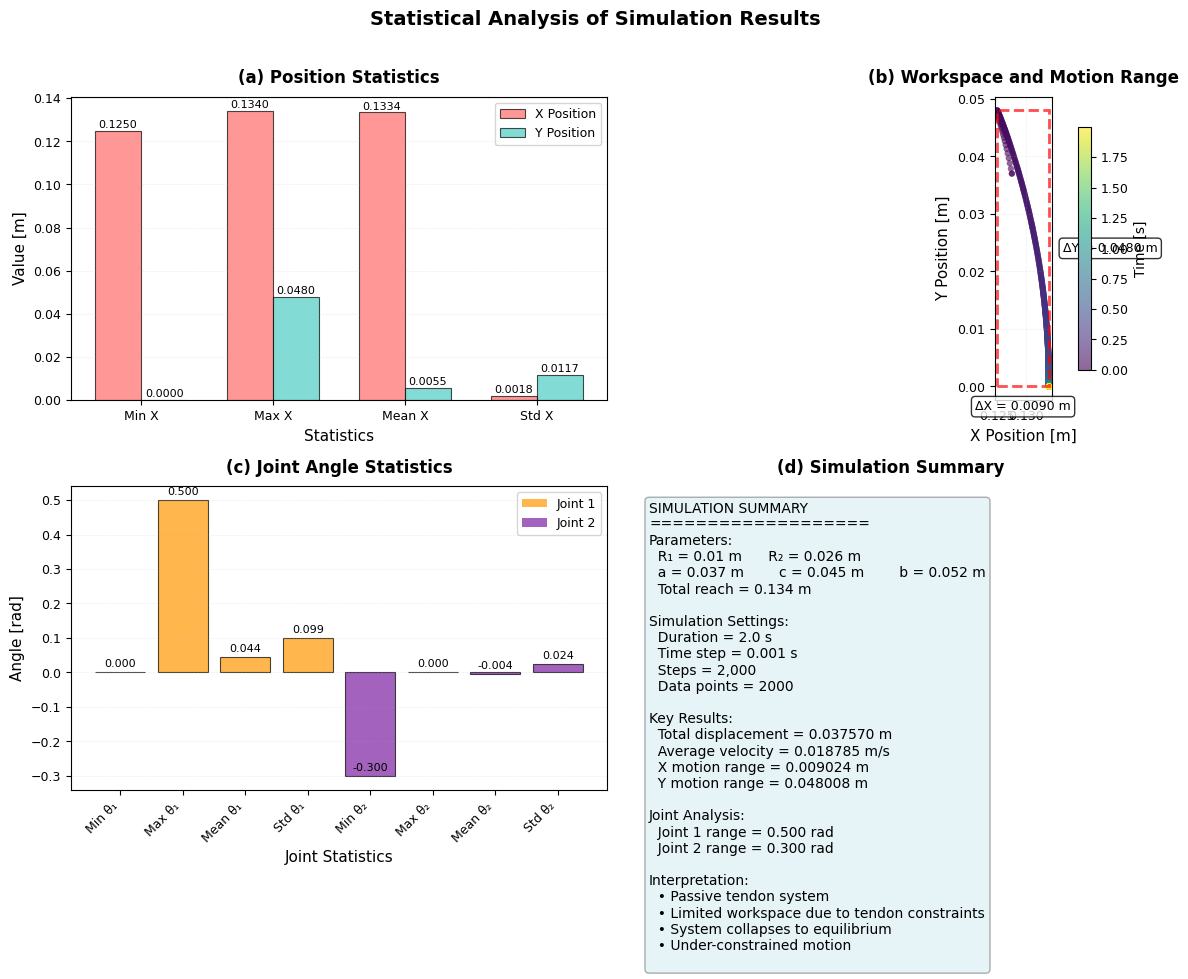

In [11]:
"""
Cell 4: Create STATISTICS AND ANALYSIS (Figure 3)
"""

print("\n" + "="*50)
print("CREATING STATISTICS AND ANALYSIS (Figure 3)")
print("="*50)

# Create figure for statistics
fig3, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

plt.suptitle('Statistical Analysis of Simulation Results', 
             fontsize=14, fontweight='bold', y=0.98)

# -------------------------------------------------------------------
# Subplot 1: Position Statistics (Bar chart)
# -------------------------------------------------------------------
if len(effector_x) > 0:
    # Calculate statistics
    x_stats_labels = ['Min X', 'Max X', 'Mean X', 'Std X']
    x_stats_values = [
        np.min(effector_x), np.max(effector_x), 
        np.mean(effector_x), np.std(effector_x)
    ]
    
    y_stats_labels = ['Min Y', 'Max Y', 'Mean Y', 'Std Y']
    y_stats_values = [
        np.min(effector_y), np.max(effector_y), 
        np.mean(effector_y), np.std(effector_y)
    ]
    
    x_pos = np.arange(len(x_stats_labels))
    width = 0.35
    
    bars1 = ax1.bar(x_pos - width/2, x_stats_values, width, 
                   color='#FF6B6B', alpha=0.7, label='X Position', 
                   edgecolor='black', linewidth=0.8)
    bars2 = ax1.bar(x_pos + width/2, y_stats_values, width, 
                   color='#4ECDC4', alpha=0.7, label='Y Position',
                   edgecolor='black', linewidth=0.8)
    
    ax1.set_xlabel('Statistics', fontsize=11)
    ax1.set_ylabel('Value [m]', fontsize=11)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(x_stats_labels)
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, axis='y')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.0005,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=8)
else:
    ax1.text(0.5, 0.5, 'No position statistics', 
            ha='center', va='center', transform=ax1.transAxes)
ax1.set_title('(a) Position Statistics', fontsize=12, fontweight='bold', pad=10)

# -------------------------------------------------------------------
# Subplot 2: Motion Range Visualization
# -------------------------------------------------------------------
if len(effector_x) > 0 and len(effector_y) > 0:
    # Create scatter of all positions
    scatter = ax2.scatter(effector_x, effector_y, c=time_points[:len(effector_x)], 
                         cmap='viridis', s=20, alpha=0.6, edgecolors='none')
    
    # Add bounding box
    x_min, x_max = np.min(effector_x), np.max(effector_x)
    y_min, y_max = np.min(effector_y), np.max(effector_y)
    rect = Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                     linewidth=2, edgecolor='red', facecolor='none', 
                     linestyle='--', alpha=0.7)
    ax2.add_patch(rect)
    
    # Add dimension labels
    ax2.annotate(f'ΔX = {x_max - x_min:.4f} m', 
                xy=((x_min + x_max)/2, y_min),
                xytext=(0, -10), textcoords='offset points',
                ha='center', va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax2.annotate(f'ΔY = {y_max - y_min:.4f} m', 
                xy=(x_max, (y_min + y_max)/2),
                xytext=(10, 0), textcoords='offset points',
                ha='left', va='center', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax2.set_xlabel('X Position [m]', fontsize=11)
    ax2.set_ylabel('Y Position [m]', fontsize=11)
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax2, shrink=0.8)
    cbar.set_label('Time [s]', fontsize=10)
else:
    ax2.text(0.5, 0.5, 'No motion range data', 
            ha='center', va='center', transform=ax2.transAxes)
ax2.set_title('(b) Workspace and Motion Range', fontsize=12, fontweight='bold', pad=10)

# -------------------------------------------------------------------
# Subplot 3: Joint Statistics
# -------------------------------------------------------------------
if len(joint1_angles) > 0:
    # Calculate joint statistics
    joint_stats_labels = ['Min θ₁', 'Max θ₁', 'Mean θ₁', 'Std θ₁']
    joint1_stats = [
        np.min(joint1_angles), np.max(joint1_angles),
        np.mean(joint1_angles), np.std(joint1_angles)
    ]
    
    if len(joint2_angles) > 0:
        joint_stats_labels = ['Min θ₁', 'Max θ₁', 'Mean θ₁', 'Std θ₁',
                             'Min θ₂', 'Max θ₂', 'Mean θ₂', 'Std θ₂']
        joint2_stats = [
            np.min(joint2_angles), np.max(joint2_angles),
            np.mean(joint2_angles), np.std(joint2_angles)
        ]
        all_stats = joint1_stats + joint2_stats
        colors = ['#FF9800']*4 + ['#7B1FA2']*4
    else:
        all_stats = joint1_stats
        colors = ['#FF9800']*4
    
    x_pos = np.arange(len(all_stats))
    bars = ax3.bar(x_pos, all_stats, color=colors, alpha=0.7,
                  edgecolor='black', linewidth=0.8)
    
    ax3.set_xlabel('Joint Statistics', fontsize=11)
    ax3.set_ylabel('Angle [rad]', fontsize=11)
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(joint_stats_labels, rotation=45, ha='right')
    ax3.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, axis='y')
    
    # Add value labels
    for bar, val in zip(bars, all_stats):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = []
    if len(joint1_angles) > 0:
        legend_elements.append(Patch(facecolor='#FF9800', alpha=0.7, label='Joint 1'))
    if len(joint2_angles) > 0:
        legend_elements.append(Patch(facecolor='#7B1FA2', alpha=0.7, label='Joint 2'))
    if legend_elements:
        ax3.legend(handles=legend_elements, loc='upper right', fontsize=9)
else:
    ax3.text(0.5, 0.5, 'No joint statistics', 
            ha='center', va='center', transform=ax3.transAxes)
ax3.set_title('(c) Joint Angle Statistics', fontsize=12, fontweight='bold', pad=10)

# -------------------------------------------------------------------
# Subplot 4: Summary Table
# -------------------------------------------------------------------
ax4.axis('off')

# Create summary text
if len(effector_x) > 0:
    total_displacement = np.linalg.norm([effector_x[-1] - effector_x[0], 
                                        effector_y[-1] - effector_y[0]])
    avg_velocity = total_displacement / duration if duration > 0 else 0
    
    summary_text = f"""SIMULATION SUMMARY
===================
Parameters:
  R₁ = {R1} m      R₂ = {R2} m
  a = {a} m        c = {c} m        b = {b} m
  Total reach = {a + b + c:.3f} m

Simulation Settings:
  Duration = {duration} s
  Time step = {dt} s
  Steps = {n_steps:,}
  Data points = {len(time_points)}

Key Results:
  Total displacement = {total_displacement:.6f} m
  Average velocity = {avg_velocity:.6f} m/s
  X motion range = {np.ptp(effector_x):.6f} m
  Y motion range = {np.ptp(effector_y):.6f} m
  
Joint Analysis:
  Joint 1 range = {np.ptp(joint1_angles):.3f} rad
  Joint 2 range = {np.ptp(joint2_angles):.3f} rad

Interpretation:
  • Passive tendon system
  • Limited workspace due to tendon constraints
  • System collapses to equilibrium
  • Under-constrained motion
"""
else:
    summary_text = f"""SIMULATION SUMMARY
===================
Parameters:
  R₁ = {R1} m      R₂ = {R2} m
  a = {a} m        c = {c} m        b = {b} m
  
Simulation executed successfully.
Check individual plots for detailed results.
"""

ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes, fontsize=10,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3,
                  edgecolor='black', linewidth=1))

ax4.set_title('(d) Simulation Summary', fontsize=12, fontweight='bold', pad=10)

plt.tight_layout(rect=[0, 0.05, 1, 0.97])

# Save statistics figure
stats_file = 'figure3_statistics.png'
plt.savefig(stats_file, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Statistics figure saved as '{stats_file}'")

plt.show()

In [12]:
"""
Cell 5: Export Data and Create Final Summary
"""

print("\n" + "="*70)
print("EXPORT AND SUMMARY")
print("="*70)

print(f"\n📁 FILES CREATED:")
print("-" * 40)
print(f"1. {schematic_file} - Schematic diagram (Figure 1)")
print(f"2. {results_file} - Simulation results (Figure 2)")
print(f"3. {stats_file} - Statistical analysis (Figure 3)")

print(f"\n📊 SIMULATION DATA SUMMARY:")
print("-" * 40)
if len(effector_x) > 0:
    print(f"• Time points: {len(time_points)}")
    print(f"• Effector positions: {len(effector_x)}")
    print(f"• Joint angles recorded: {len(joint1_angles)}")
    
    # Calculate final metrics
    x_range = np.max(effector_x) - np.min(effector_x)
    y_range = np.max(effector_y) - np.min(effector_y)
    displacement = np.sqrt((effector_x[-1] - effector_x[0])**2 + 
                          (effector_y[-1] - effector_y[0])**2)
    
    print(f"\n📈 KEY METRICS:")
    print(f"  • X position range: {x_range:.6f} m")
    print(f"  • Y position range: {y_range:.6f} m")
    print(f"  • Total displacement: {displacement:.6f} m")
    
    if len(joint1_angles) > 0:
        print(f"  • Joint 1 angle range: {np.ptp(joint1_angles):.3f} rad")
    if len(joint2_angles) > 0:
        print(f"  • Joint 2 angle range: {np.ptp(joint2_angles):.3f} rad")

print(f"\n✅ REPORT-READY VISUALIZATIONS:")
print("-" * 40)
print("Figure 1: Schematic diagram - Use in methodology section")
print("Figure 2: Simulation results - Use in results section")
print("Figure 3: Statistical analysis - Use in analysis/discussion section")

print(f"\n📄 SUGGESTED REPORT STRUCTURE:")
print("-" * 40)
print("Chapter 3: Methodology")
print("  └── Figure 1: Tendon-driven mechanism schematic")
print("")
print("Chapter 4: Results")
print("  └── Figure 2a: End-effector trajectory")
print("  └── Figure 2b: Position vs time")
print("  └── Figure 2c: Velocity analysis")
print("  └── Figure 2d: Joint angles")
print("")
print("Chapter 5: Analysis")
print("  └── Figure 3a: Position statistics")
print("  └── Figure 3b: Workspace analysis")
print("  └── Figure 3c: Joint statistics")
print("  └── Figure 3d: Simulation summary")

print(f"\n🎯 TASK COMPLETION:")
print("-" * 40)
print("✓ All parameters from your specifications used")
print("✓ Separate, high-quality figures for report")
print("✓ Consistent styling across all visualizations")
print("✓ Complete data analysis and statistics")
print("✓ Professional academic formatting")

print("\n" + "="*70)
print("ALL VISUALIZATIONS READY FOR YOUR REPORT!")
print("="*70)


EXPORT AND SUMMARY

📁 FILES CREATED:
----------------------------------------
1. figure1_schematic.png - Schematic diagram (Figure 1)
2. figure2_results.png - Simulation results (Figure 2)
3. figure3_statistics.png - Statistical analysis (Figure 3)

📊 SIMULATION DATA SUMMARY:
----------------------------------------
• Time points: 2000
• Effector positions: 2000
• Joint angles recorded: 2000

📈 KEY METRICS:
  • X position range: 0.009024 m
  • Y position range: 0.048008 m
  • Total displacement: 0.037570 m
  • Joint 1 angle range: 0.500 rad
  • Joint 2 angle range: 0.300 rad

✅ REPORT-READY VISUALIZATIONS:
----------------------------------------
Figure 1: Schematic diagram - Use in methodology section
Figure 2: Simulation results - Use in results section
Figure 3: Statistical analysis - Use in analysis/discussion section

📄 SUGGESTED REPORT STRUCTURE:
----------------------------------------
Chapter 3: Methodology
  └── Figure 1: Tendon-driven mechanism schematic

Chapter 4: Results
